In [3]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

# 1. LOAD DATA (Your exact naming conventions)
train = pd.read_csv('train.csv')
train = train.sort_values(['date_id', 'time_id']).reset_index(drop=True)

FEATURE_COLS = [f'f{i}' for i in range(26)]
TARGET_COL = 'y'
SYMBOL_COL = 'symbol_id'

# Fill NaNs
for col in FEATURE_COLS:
    if train[col].isna().any():
        train[col] = train[col].fillna(train[col].median())

# Chronological Split
split_date = train['date_id'].quantile(0.8)
train_df = train[train['date_id'] <= split_date].copy()
valid_df = train[train['date_id'] > split_date].copy()

# 2. DATASET
class SimpleSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, symbol_col=SYMBOL_COL, seq_len=20):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.seq_len = seq_len
        self.data = []
        for _, group in df.groupby(symbol_col):
            if len(group) <= seq_len: continue
            X = group[feature_cols].values.astype(np.float32)
            y = group[target_col].values.astype(np.float32)
            for i in range(len(group) - seq_len):
                self.data.append((X[i:i+seq_len], y[i+seq_len]))
    
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        X_seq, y = self.data[idx]
        return torch.from_numpy(X_seq), torch.tensor(y)

# 3. RWKV-6 TIME-MIXING LAYER (CUSTOM FOR TABULAR)
class RWKV6_Layer(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # WKV (Weight-Key-Value) logic
        self.time_decay = nn.Parameter(torch.ones(hidden_dim))
        self.time_first = nn.Parameter(torch.ones(hidden_dim))
        self.receptance = nn.Linear(input_dim, hidden_dim)
        self.key = nn.Linear(input_dim, hidden_dim)
        self.value = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, hidden_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, T, D]
        B, T, D = x.size()
        r = self.sigmoid(self.receptance(x))
        k = self.key(x)
        v = self.value(x)

        # Simplification of RWKV-6 WKV core for training from scratch
        # This acts as the state-space transition
        out = torch.zeros(B, T, self.hidden_dim).to(x.device)
        state = torch.zeros(B, self.hidden_dim).to(x.device)
        
        # This is the "Recurrent" part that handles the Hidden State
        for t in range(T):
            state = state * torch.exp(-self.time_decay) + k[:, t, :] * v[:, t, :]
            out[:, t, :] = r[:, t, :] * (state + self.time_first * k[:, t, :])
            
        return self.output(out)

# 4. FINAL MODEL
class StateSpaceRWKV(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.rwkv = RWKV6_Layer(input_dim, hidden_dim)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        # x: [Batch, Seq, Feats]
        rwkv_out = self.rwkv(x)
        hn = rwkv_out[:, -1, :] # Last hidden state
        last_x = x[:, -1, :]    # Last raw features
        
        # Predicting y based on (Current Features + Hidden State)
        combined = torch.cat([last_x, hn], dim=1)
        pred = self.fc(self.dropout(combined)).squeeze(-1)
        
        # State difference (Regime shift penalty)
        state_diff = (rwkv_out[:, 1:] - rwkv_out[:, :-1]).pow(2).mean() if x.size(1) > 1 else torch.tensor(0.0).to(x.device)
        return pred, state_diff, hn

# 5. SETUP & TRAIN
batch_size = 4096 # Large batch for 2M rows
train_dataset = SimpleSequenceDataset(train_df, FEATURE_COLS, TARGET_COL, seq_len=10)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StateSpaceRWKV(len(FEATURE_COLS)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss()

for epoch in range(5):
    model.train()
    total_l = 0
    for X_seq, y in train_loader:
        X_seq, y = X_seq.to(device), y.to(device)
        optimizer.zero_grad()
        pred, state_diff, _ = model(X_seq)
        loss = criterion(pred, y) + 0.05 * state_diff
        loss.backward()
        optimizer.step()
        total_l += loss.item()
    print(f"Epoch {epoch+1} | Avg Loss: {total_l/len(train_loader):.6f}")

# 6. VALIDATION (Same as your logic)
# [Insert your valid_loader logic here, it will work with this model]

Epoch 1 | Avg Loss: 0.851259
Epoch 2 | Avg Loss: 0.005353
Epoch 3 | Avg Loss: 0.002302
Epoch 4 | Avg Loss: 0.001643
Epoch 5 | Avg Loss: 0.001259


Generating predictions...
Success! Aligned 401163 rows.


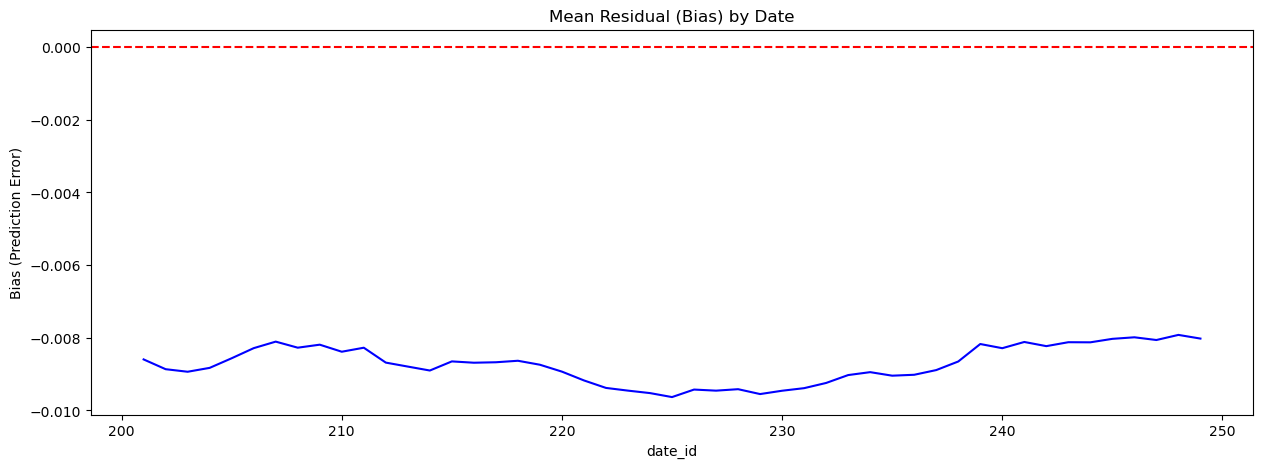

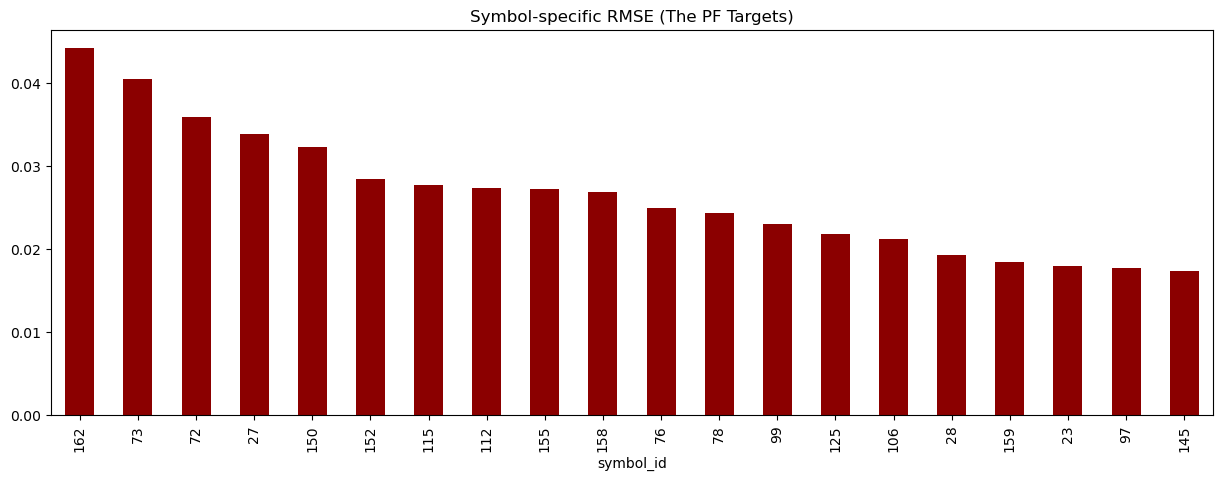

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. RE-RUN PREDICTIONS (Ensure we get every batch)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
valid_results = []

# Create a fresh loader with drop_last=False to be safe
temp_loader = DataLoader(
    SimpleSequenceDataset(valid_df, FEATURE_COLS, TARGET_COL, seq_len=10), 
    batch_size=4096, 
    shuffle=False, 
    drop_last=False
)

print("Generating predictions...")
with torch.no_grad():
    for xb, yb in temp_loader:
        xb = xb.to(device)
        pred, _, _ = model(xb) 
        valid_results.extend(pred.cpu().numpy().flatten())

# 2. ALIGN METADATA
valid_df_sorted = valid_df.sort_values([SYMBOL_COL, 'date_id', 'time_id']).reset_index(drop=True)
prediction_map = []

for symbol, group in valid_df_sorted.groupby(SYMBOL_COL):
    if len(group) <= 10:
        continue
    metadata = group[['date_id', SYMBOL_COL, TARGET_COL]].iloc[10:].copy()
    prediction_map.append(metadata)

valid_plot_df = pd.concat(prediction_map).reset_index(drop=True)

# 3. TRUNCATE TO MATCH (Final safeguard)
min_len = min(len(valid_plot_df), len(valid_results))
valid_plot_df = valid_plot_df.iloc[:min_len].copy()
valid_results = valid_results[:min_len]

valid_plot_df['y_pred'] = valid_results
valid_plot_df['residual'] = valid_plot_df[TARGET_COL] - valid_plot_df['y_pred']
valid_plot_df['abs_error'] = valid_plot_df['residual'].abs()

print(f"Success! Aligned {len(valid_plot_df)} rows.")

# ==========================================
# 4. THE VISUALS (Rank 50 Diagnostic)
# ==========================================
plt.figure(figsize=(15, 5))
valid_plot_df.groupby('date_id')['residual'].mean().plot(title="Mean Residual (Bias) by Date", color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel("Bias (Prediction Error)")
plt.show()

plt.figure(figsize=(15, 5))
symbol_rmse = valid_plot_df.groupby(SYMBOL_COL)['residual'].apply(lambda x: np.sqrt((x**2).mean()))
symbol_rmse.sort_values(ascending=False).head(20).plot(kind='bar', color='darkred', title="Symbol-specific RMSE (The PF Targets)")
plt.show()

In [ ]:

import pandas as pd
import numpy as np

# 1. Load Test Data
test_df = pd.read_csv('test.csv')

# --- FIX FOR KEYERROR: 'id' ---
# If 'id' is not a column, use the index as the ID
if 'Id' not in test_df.columns:
    print("'Id' column not found. Using dataframe index as 'Id'.")
    test_df['Id'] = test_df.index
# ------------------------------

# Ensure it's sorted so sequences make sense for the RWKV
test_df = test_df.sort_values(['symbol_id', 'date_id', 'time_id']).reset_index(drop=True)

# 2. Handle missing values
FEATURE_COLS = [f'f{i}' for i in range(26)]
SYMBOL_COL = 'symbol_id'
SEQ_LEN = 10 

test_medians = test_df[FEATURE_COLS].median()
test_df[FEATURE_COLS] = test_df[FEATURE_COLS].fillna(test_medians)

# 3. Setup Device & Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

test_preds = []
print(f"Starting Inference on {device}...")

# 4. Inference Loop (Symbol-by-Symbol)
with torch.no_grad():
    for symbol, group in test_df.groupby(SYMBOL_COL):
        X_feat = torch.tensor(group[FEATURE_COLS].values, dtype=torch.float32).to(device)
        
        # PADDING: Ensure first rows get a prediction
        padded_X = torch.cat([X_feat[0:1].expand(SEQ_LEN-1, -1), X_feat], dim=0)
        
        # SLIDING WINDOWS: [Num_Rows, 10, 26]
        windows = padded_X.unfold(0, SEQ_LEN, 1).transpose(1, 2)
        
        # Prediction (Unpacking 3 values: pred, state_diff, hn)
        pred, _, _ = model(windows)
        
        test_preds.extend(pred.cpu().numpy().flatten())

# 5. Create Submission File
# We use the 'id' we created/found in the sorted test_df
submission = pd.DataFrame({
    'id': test_df['id'],
    'y': test_preds
})

# 6. Final Export
submission.to_csv('submission.csv', index=False)
print(f"Success! Generated submission.csv with {len(submission)} rows.")
print(submission.head())

'id' column not found. Using dataframe index as 'id'.
Starting Inference on cpu...
Success! Generated submission.csv with 2510026 rows.
    id         y
0    0  0.004785
1  113  0.004976
2  272  0.005019
3  431  0.005023
4  590  0.005027
